# Capítulo 36 — Visualizar relaciones entre variables numéricas

## Observar relaciones entre columnas

En el capítulo anterior comparamos distribuciones de variables numéricas entre distintos grupos. Por ejemplo, analizamos cómo cambiaban `total_bill` y `tip` según el horario o el día.

Ahora vamos a mirar otro tipo de relación. En lugar de comparar una variable numérica según una categoría, vamos a observar dos variables numéricas al mismo tiempo. La pregunta principal será:

**¿hay alguna relación entre el importe total de la cuenta y la propina?**

Para responderla vamos a trabajar con dos columnas del dataset `tips`:

- `total_bill`, que representa el importe total de la cuenta;
- `tip`, que representa el monto de la propina.

La idea será construir gráficos que nos permitan ver si, cuando una variable aumenta, la otra también tiende a aumentar.

## Cargar el dataset

Como en los capítulos anteriores, vamos a trabajar con el dataset `tips`. Primero importamos las librerías necesarias y cargamos los datos.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset `tips`. Cada fila representa una cuenta registrada en un restaurante. En este capítulo vamos a observar especialmente dos columnas numéricas:

* `total_bill`, que indica el importe total de la cuenta;
* y `tip`, que indica el monto de la propina.

La pregunta inicial será:

**¿las cuentas más altas suelen estar asociadas con propinas más altas?**

Para empezar a responder, vamos a construir un gráfico de dispersión.

## Primer gráfico de relación: scatterplot

Un gráfico de dispersión, o `scatterplot`, permite visualizar la relación entre dos variables numéricas. Cada punto del gráfico representa una fila del dataset.

En nuestro caso:

- el eje horizontal mostrará `total_bill`;
- el eje vertical mostrará `tip`;
- cada punto representará una cuenta.

Si los puntos tienden a subir a medida que avanzan hacia la derecha, eso puede sugerir una relación positiva entre las variables.

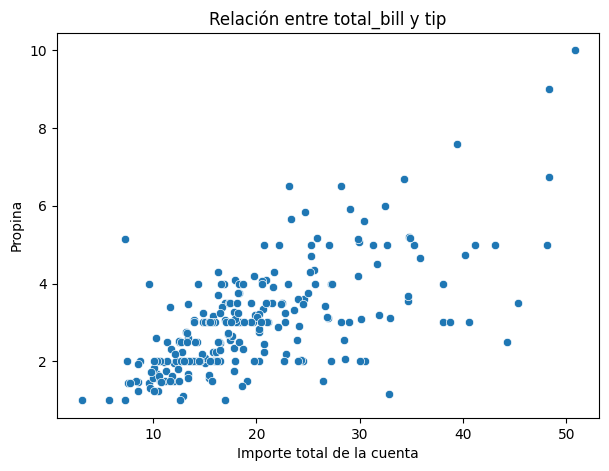

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Relación entre total_bill y tip")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Propina")

plt.show()

El gráfico de dispersión muestra la relación entre el importe total de la cuenta y la propina. Cada punto representa una cuenta del dataset.

En el eje horizontal aparece `total_bill`, es decir, el importe total de la cuenta.

En el eje vertical aparece `tip`, es decir, el monto de la propina.

La nube de puntos sugiere una relación positiva: en general, cuando el importe de la cuenta aumenta, la propina también tiende a aumentar. Sin embargo, la relación no es perfecta.

Para importes similares, pueden aparecer propinas diferentes. Por ejemplo, hay cuentas cercanas a 20 con propinas que van aproximadamente desde 2 hasta 5.

Esto nos recuerda que una relación entre variables no significa que todos los puntos sigan exactamente el mismo patrón. En datos reales, suele haber variación.

## Leer un gráfico de dispersión

En un `scatterplot`, cada punto representa una observación.

La posición horizontal del punto depende del valor de una variable.

La posición vertical depende del valor de otra variable.

En este caso:

- si un punto está más a la derecha, representa una cuenta con mayor `total_bill`;
- si un punto está más arriba, representa una propina mayor;
- si muchos puntos forman una dirección ascendente, puede haber una relación positiva entre las variables.

Una relación positiva significa que, cuando una variable aumenta, la otra tiende a aumentar también.

Pero todavía estamos haciendo una lectura visual. Para complementar esa lectura, podemos calcular una medida numérica de relación.

## Medir la relación con correlación

Una forma de resumir la relación lineal entre dos variables numéricas es calcular la correlación. La correlación puede tomar valores entre -1 y 1.

De manera general:

- valores cercanos a 1 indican una relación positiva fuerte;
- valores cercanos a -1 indican una relación negativa fuerte;
- valores cercanos a 0 indican poca relación lineal.

Vamos a calcular la correlación entre `total_bill` y `tip`.

In [ ]:
correlacion_total_tip = df["total_bill"].corr(df["tip"])

round(float(correlacion_total_tip), 2)

0.68

La correlación entre `total_bill` y `tip` es aproximadamente 0.68. Este valor es positivo, por lo que coincide con lo que vimos en el gráfico: cuando el importe total de la cuenta aumenta, la propina tiende a aumentar. No es una correlación perfecta, porque no vale 1.

Esto también coincide con el gráfico de dispersión: los puntos muestran una tendencia ascendente, pero no están ubicados exactamente sobre una línea.

En términos prácticos, podemos decir que en este dataset hay una relación positiva moderada entre el importe total de la cuenta y la propina.

Es importante recordar que la correlación resume una relación lineal. Puede ser útil, pero no reemplaza la visualización.

## Agregar una línea de tendencia

Para observar mejor la dirección general de la relación, podemos agregar una línea de tendencia.

Seaborn tiene una función llamada `regplot()` que combina:

- un gráfico de dispersión;
- una línea de tendencia.

Esto nos ayuda a ver si la relación general entre las variables es ascendente, descendente o casi plana.

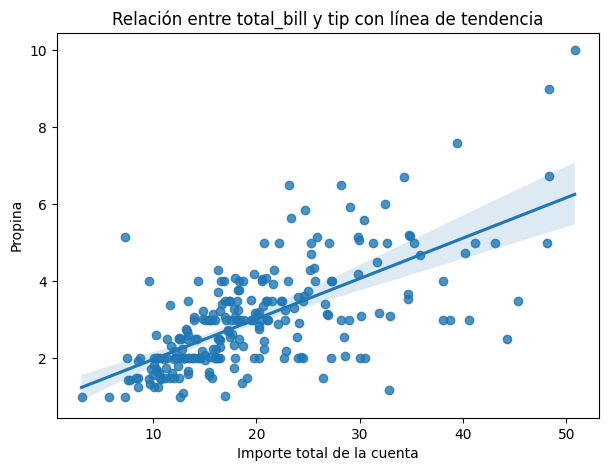

In [ ]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Relación entre total_bill y tip con línea de tendencia")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Propina")

plt.show()

El gráfico vuelve a mostrar la relación entre `total_bill` y `tip`, pero ahora agrega una línea de tendencia. La línea tiene una inclinación ascendente.

Esto refuerza la idea de que existe una relación positiva entre ambas variables: a medida que aumenta el importe total de la cuenta, la propina tiende a aumentar.

También se observa una banda clara alrededor de la línea. Esa banda representa una zona de incertidumbre o variación alrededor de la tendencia estimada. Es importante notar que la línea no pasa exactamente por todos los puntos. Esto ocurre porque la relación no es perfecta. Hay cuentas con importes parecidos que tienen propinas diferentes, y también hay algunos puntos alejados del patrón general.

La línea de tendencia resume la dirección general, pero no elimina la variabilidad de los datos.

## Cómo leer `regplot`

En la celda anterior usamos `sns.regplot()`.

La instrucción principal fue:

```python
sns.regplot(
    data=df,
    x="total_bill",
    y="tip"
)
```

Esta función combina dos elementos: un gráfico de dispersión y una línea de tendencia.

El argumento `data=df` indica qué DataFrame vamos a usar.

El argumento `x="total_bill"` ubica el importe total de la cuenta en el eje horizontal.

El argumento `y="tip"` ubica la propina en el eje vertical.

Cuando la línea sube hacia la derecha, la relación general es positiva.

Cuando la línea baja hacia la derecha, la relación general es negativa.

Cuando la línea queda casi horizontal, la relación lineal es débil o casi inexistente.


## Agregar una variable categórica con color

Hasta ahora analizamos la relación entre `total_bill` y `tip` usando solo dos variables numéricas. Ahora vamos a sumar una variable categórica para enriquecer la lectura. Podemos usar el color de los puntos para distinguir grupos.

Por ejemplo, vamos a colorear los puntos según el horario de la cuenta:

- `Lunch`;
- `Dinner`.

La pregunta será:

**¿la relación entre importe total y propina se ve parecida en almuerzo y cena?**

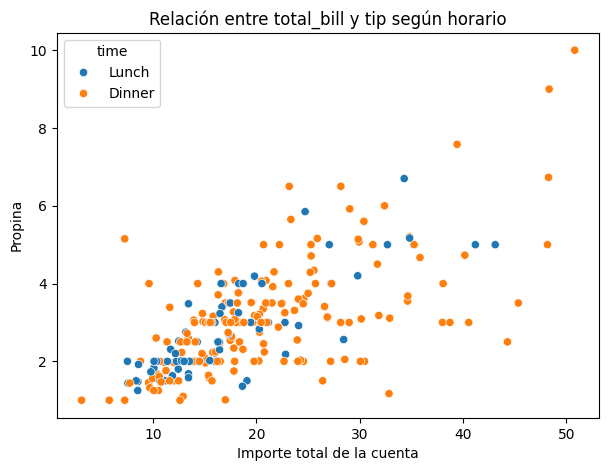

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time"
)

plt.title("Relación entre total_bill y tip según horario")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Propina")

plt.show()

El gráfico muestra la relación entre `total_bill` y `tip`, separando los puntos por horario.

* Los puntos azules corresponden a `Lunch`.
* Los puntos naranjas corresponden a `Dinner`.

La relación positiva general se mantiene: en ambos horarios, las cuentas más altas tienden a asociarse con propinas más altas.

También se observa que hay muchos más puntos de `Dinner` que de `Lunch`, algo que ya habíamos visto en capítulos anteriores.

Además, varios de los valores más altos de `total_bill` y `tip` aparecen en `Dinner`.

Esto no significa que todas las cenas tengan importes o propinas altos, sino que en este dataset los valores más grandes se observan principalmente en ese horario.

El color nos ayuda a ver si la relación general se comporta de manera parecida o diferente entre grupos.

## Leer `hue` en un scatterplot

En la celda anterior usamos nuevamente el argumento `hue`.

La instrucción principal fue:

```python
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time"
)
```

El argumento `x="total_bill"` ubica el importe total de la cuenta en el eje horizontal.

El argumento `y="tip"` ubica la propina en el eje vertical.

El argumento `hue="time"` colorea los puntos según el horario.

Esto permite sumar una tercera variable al gráfico. Ya no miramos solamente la relación entre dos variables numéricas, sino que también podemos observar si esa relación cambia entre categorías.

## Calcular la correlación por horario

Como agregamos la variable `time`, podemos preguntarnos si la relación entre `total_bill` y `tip` es igual en `Lunch` y en `Dinner`. Para explorarlo, vamos a calcular la correlación por separado para cada horario. Esto nos permitirá comparar la relación numérica dentro de cada grupo.

In [ ]:
correlacion_lunch = df.loc[df["time"] == "Lunch", "total_bill"].corr(
    df.loc[df["time"] == "Lunch", "tip"]
)

correlacion_dinner = df.loc[df["time"] == "Dinner", "total_bill"].corr(
    df.loc[df["time"] == "Dinner", "tip"]
)

correlacion_por_horario = pd.DataFrame({
    "horario": ["Lunch", "Dinner"],
    "correlacion_total_bill_tip": [correlacion_lunch, correlacion_dinner]
})

correlacion_por_horario["correlacion_total_bill_tip"] = correlacion_por_horario["correlacion_total_bill_tip"].round(2)

correlacion_por_horario

,horario,correlacion_total_bill_tip
0,Lunch,0.81
1,Dinner,0.63


La tabla muestra la correlación entre `total_bill` y `tip` calculada por separado para cada horario.

* En `Lunch`, la correlación es 0.81.
* En `Dinner`, la correlación es 0.63.

En ambos casos la correlación es positiva. Esto significa que, tanto en almuerzo como en cena, las cuentas más altas tienden a estar asociadas con propinas más altas.

Sin embargo, la correlación es más alta en `Lunch` que en `Dinner`.

Esto sugiere que, dentro de los almuerzos, la relación lineal entre importe total y propina es más fuerte que dentro de las cenas.

De todos modos, debemos interpretar esta comparación con cuidado, porque no hay la misma cantidad de datos en ambos grupos: `Lunch` tiene menos registros que `Dinner`.

## Cuidado: correlación no significa causalidad

La correlación nos ayuda a describir una relación entre dos variables numéricas. Pero es importante hacer una aclaración: **correlación no significa causalidad.**

En este caso, vemos que `total_bill` y `tip` tienen una relación positiva. Eso no alcanza para afirmar, de manera general, que una variable sea la única causa de la otra. Lo que sí podemos decir, de forma prudente, es que en este dataset las cuentas de mayor importe suelen estar asociadas con propinas más altas.

La correlación resume una relación, pero no explica por sí sola todos los motivos detrás de esa relación.

## Otra relación: importe total y tamaño del grupo

Además de `total_bill` y `tip`, el dataset tiene otra columna numérica interesante: `size`. La columna `size` indica la cantidad de personas asociadas a la cuenta. Podemos preguntarnos:

**¿las cuentas de grupos más grandes tienden a tener importes más altos?**

Para explorar esta relación vamos a construir otro gráfico de dispersión.

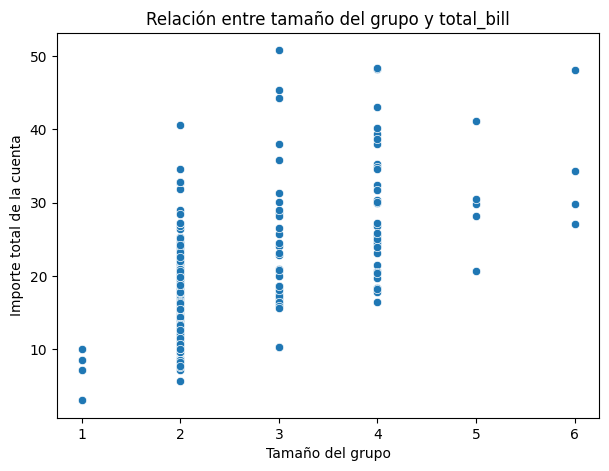

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="size",
    y="total_bill"
)

plt.title("Relación entre tamaño del grupo y total_bill")
plt.xlabel("Tamaño del grupo")
plt.ylabel("Importe total de la cuenta")

plt.show()

El gráfico muestra la relación entre el tamaño del grupo y el importe total de la cuenta.

En el eje horizontal aparece `size`, que indica la cantidad de personas asociadas a la cuenta.

En el eje vertical aparece `total_bill`, el importe total de la cuenta.

A diferencia de `total_bill` y `tip`, la variable `size` solo toma algunos valores enteros: 1, 2, 3, 4, 5 y 6. Por eso los puntos aparecen agrupados en columnas verticales.

La lectura general sugiere que los grupos más grandes tienden a tener cuentas más altas. Sin embargo, también se observa bastante variación dentro de cada tamaño de grupo. Por ejemplo, para grupos de 2 personas hay cuentas de importes muy distintos. Lo mismo ocurre con grupos de 3 y 4 personas.

Esto muestra que el tamaño del grupo puede estar relacionado con el importe total, pero no lo explica completamente.

## Cuando una variable numérica tiene pocos valores

Aunque `size` es una variable numérica, no se comporta igual que `total_bill` o `tip`. `total_bill` y `tip` pueden tomar muchos valores diferentes. En cambio, `size` representa una cantidad de personas y solo toma algunos valores enteros.

Cuando usamos un scatterplot con una variable de este tipo, muchos puntos pueden quedar encimados en las mismas posiciones del eje horizontal. Por eso, antes de seguir interpretando, conviene mirar cuántos registros hay para cada tamaño de grupo.

In [ ]:
conteo_size = df["size"].value_counts().sort_index()

conteo_size

,count
size,
1,4
2,156
3,38
4,37
5,5
6,4


La tabla muestra cuántas cuentas hay para cada valor de `size`. La mayoría de las cuentas corresponde a grupos de 2 personas: hay 156 registros.

Luego aparecen grupos de 3 y 4 personas, con cantidades bastante menores. En cambio, los grupos de 1, 5 y 6 personas tienen muy pocos registros. Esto es importante para interpretar el gráfico anterior. Aunque parece haber una relación positiva entre `size` y `total_bill`, no todos los tamaños de grupo tienen la misma cantidad de datos.

Por ejemplo, hay muy pocos casos con `size` igual a 5 o 6. Por eso, las conclusiones sobre esos tamaños deben tomarse con cuidado.

Una vez más, la cantidad de registros por grupo nos ayuda a leer mejor la visualización.

## Calcular la correlación entre `size` y `total_bill`

Ahora vamos a calcular la correlación entre `size` y `total_bill`. Esto nos permitirá resumir numéricamente la relación que vimos en el gráfico.

De todos modos, debemos recordar algo importante: como `size` tiene pocos valores posibles, la correlación debe interpretarse junto con el gráfico y con el conteo de registros por tamaño de grupo.

In [ ]:
correlacion_size_total = df["size"].corr(df["total_bill"])

round(float(correlacion_size_total), 2)

0.6

La correlación entre `size` y `total_bill` es aproximadamente 0.60. Este valor es positivo. Eso significa que, en este dataset, los grupos más grandes tienden a estar asociados con cuentas de mayor importe. Esta lectura coincide con el gráfico de dispersión anterior.

Sin embargo, la relación no es perfecta. Dentro de un mismo tamaño de grupo hay cuentas con importes muy diferentes. Por ejemplo, entre los grupos de 2 personas aparecen cuentas bajas, medias y algunas bastante altas.

Además, algunos tamaños de grupo tienen muy pocos registros, como 1, 5 y 6. Por eso, esta correlación es útil como resumen, pero debe interpretarse junto con la visualización y con el conteo de registros.

## Mejorar la visualización con `jitter`

En el gráfico anterior, muchos puntos quedaron alineados verticalmente porque `size` tiene pocos valores posibles. Podemos mejorar la visualización agregando una pequeña variación horizontal a los puntos. A esa pequeña variación se la suele llamar `jitter`.

El `jitter` no cambia los datos reales, solo separa un poco los puntos en el gráfico para que se vean mejor.

Para eso vamos a usar `stripplot`, que ya usamos en el capítulo anterior.

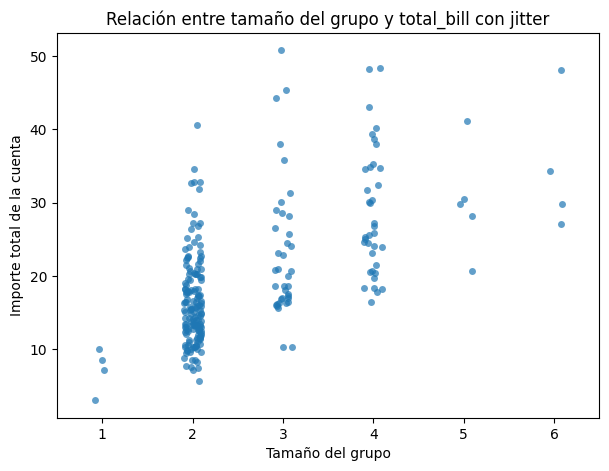

In [ ]:
plt.figure(figsize=(7, 5))

sns.stripplot(
    data=df,
    x="size",
    y="total_bill",
    jitter=True,
    alpha=0.7
)

plt.title("Relación entre tamaño del grupo y total_bill con jitter")
plt.xlabel("Tamaño del grupo")
plt.ylabel("Importe total de la cuenta")

plt.show()

El gráfico con `jitter` muestra la relación entre `size` y `total_bill` de una manera más legible. Cada punto sigue representando una cuenta.

La diferencia es que ahora los puntos tienen una pequeña separación horizontal dentro de cada valor de `size`. Esto permite ver mejor cuántos registros hay en cada tamaño de grupo. Por ejemplo, se nota claramente que hay muchos registros con `size = 2`.

También se observa que los tamaños 1, 5 y 6 tienen pocos puntos, tal como mostraba la tabla de conteo.

La lectura general se mantiene: los grupos más grandes tienden a tener cuentas más altas, pero hay bastante variación dentro de cada tamaño.

El `jitter` no cambia los valores reales de `size`. Solo ayuda a evitar que muchos puntos queden completamente encimados en el gráfico.

## Comparar varias correlaciones

Hasta ahora calculamos correlaciones entre pares de variables:

`total_bill` y `tip`;

`size` y `total_bill`.

Pero también podemos calcular una matriz de correlación entre todas las variables numéricas del dataset.

En este caso, vamos a seleccionar:

- `total_bill`;
- `tip`;
- `size`.

La matriz de correlación nos permitirá ver, en una sola tabla, cómo se relacionan estas variables entre sí.

In [ ]:
columnas_numericas = ["total_bill", "tip", "size"]

matriz_correlacion = df[columnas_numericas].corr().round(2)

matriz_correlacion

,total_bill,tip,size
total_bill,1.00,0.68,0.60
tip,0.68,1.00,0.49
size,0.60,0.49,1.00


La matriz de correlación muestra la relación entre cada par de variables numéricas. La diagonal principal tiene valores iguales a 1.00 porque cada variable tiene correlación perfecta consigo misma.

Fuera de la diagonal podemos leer las relaciones entre variables distintas:

- `total_bill` y `tip` tienen una correlación de 0.68;
- `total_bill` y `size` tienen una correlación de 0.60;
- `tip` y `size` tienen una correlación de 0.49.

Las tres correlaciones son positivas.

Esto indica que, en este dataset:

* las cuentas más altas tienden a asociarse con propinas más altas;
* los grupos más grandes tienden a asociarse con cuentas más altas;

y los grupos más grandes también tienden a asociarse con propinas más altas, aunque esta relación es más débil que las anteriores.

Como siempre, la correlación resume una relación lineal, pero no reemplaza la interpretación visual ni el conocimiento del contexto.

## Visualizar la matriz de correlación

Una matriz de correlación también puede visualizarse con un mapa de calor, o `heatmap`. En un mapa de calor, los valores se representan usando colores.Esto permite identificar rápidamente qué relaciones son más fuertes o más débiles.

Vamos a construir un `heatmap` con las correlaciones entre `total_bill`, `tip` y `size`.

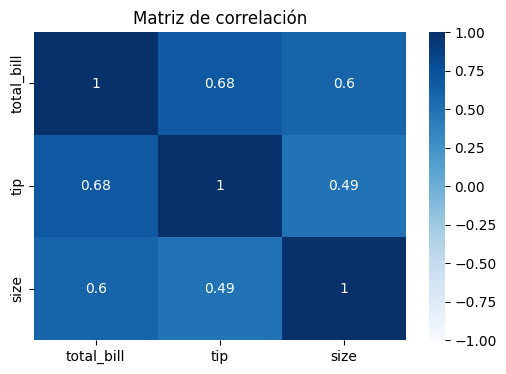

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")
plt.show()

El mapa de calor representa visualmente la matriz de correlación. Cada celda muestra la correlación entre dos variables. Los valores también aparecen escritos dentro de cada celda porque usamos `annot=True`.

La diagonal principal tiene valores iguales a 1, ya que cada variable se compara consigo misma. En este caso, todas las correlaciones son positivas.

La relación más alta entre variables distintas es la de `total_bill` y `tip`, con una correlación de 0.68. Luego aparece la relación entre `total_bill` y `size`, con una correlación de 0.60. La relación más débil de las tres es la de `tip` y `size`, con una correlación de 0.49.

El color ayuda a identificar rápidamente qué relaciones son más fuertes, pero siempre conviene leer también los valores numéricos.

## Cómo leer `heatmap`

En la celda anterior usamos `sns.heatmap()`.

La instrucción principal fue:

```python
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1
)
```

El argumento `matriz_correlacion` indica qué tabla queremos visualizar.

El argumento `annot=True` muestra los valores dentro de cada celda.

El argumento `cmap="Blues"` define la paleta de colores.

Los argumentos `vmin=-1` y `vmax=1` fijan la escala de la correlación entre -1 y 1.

Esto es útil porque la correlación siempre se interpreta dentro de ese rango.

Si usamos la misma escala para distintos mapas de calor, las comparaciones visuales son más consistentes.

## Cierre del capítulo

En este capítulo aprendimos a visualizar relaciones entre variables numéricas.

Usamos `scatterplot` para observar la relación entre dos columnas numéricas. También usamos `regplot` para agregar una línea de tendencia.

Calculamos correlaciones para resumir numéricamente la relación lineal entre variables.

Además, vimos que podemos sumar una variable categórica con `hue` para enriquecer la lectura del gráfico.

Por último, construimos una matriz de correlación y la visualizamos con `heatmap`.

Lo más importante es recordar que una relación entre variables no debe interpretarse mirando una sola herramienta. Un gráfico muestra patrones visuales. La correlación resume una relación lineal.Y el contexto nos ayuda a interpretar qué puede significar esa relación dentro del dataset.

En el próximo capítulo vamos a seguir trabajando con visualizaciones, pero orientadas a comunicar resultados de manera más clara y ordenada.